In [1]:
## impute the misisng values 
# univariant in numerical : fill with mean/median if skewed use median 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('/Users/khushi/AI-ML/100DAYS(ML)/train.csv')

In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.isnull().mean()


PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:

X_train.shape, X_test.shape

((712, 11), (179, 11))

In [8]:

X_train.isnull().mean()

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.207865
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.775281
Embarked       0.002809
dtype: float64

In [9]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [10]:

X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [11]:
X_train.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_median,Age_mean,Fare_median,Fare_mean
612,613,3,"Murphy, Miss. Margaret Jane",female,NaN,1,0,367230,15.5000,NaN,Q,28.75,29.785904,15.5000,15.5000
404,405,3,"Oreskovic, Miss. Marija",female,20.0,0,0,315096,8.6625,NaN,S,20.00,20.000000,8.6625,8.6625
326,327,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S,61.00,61.000000,6.2375,6.2375
881,882,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S,33.00,33.000000,7.8958,7.8958
826,827,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S,28.75,29.785904,56.4958,56.4958


In [12]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  204.34951339046142
Age Variance after median imputation:  161.98956633460548
Age Variance after mean imputation:  161.81262452718676
Original Fare variable variance:  2368.2468324201327
Fare Variance after median imputation:  2368.2468324201327
Fare Variance after mean imputation:  2368.2468324201327


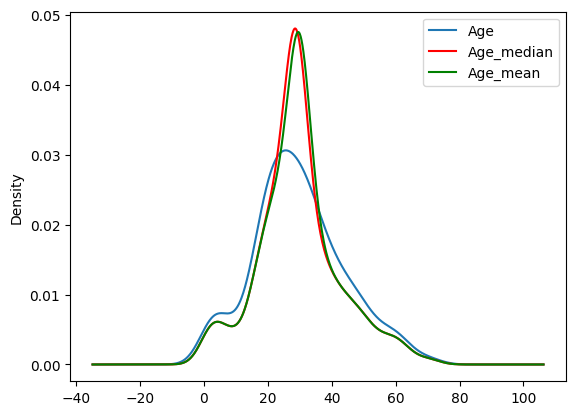

In [13]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

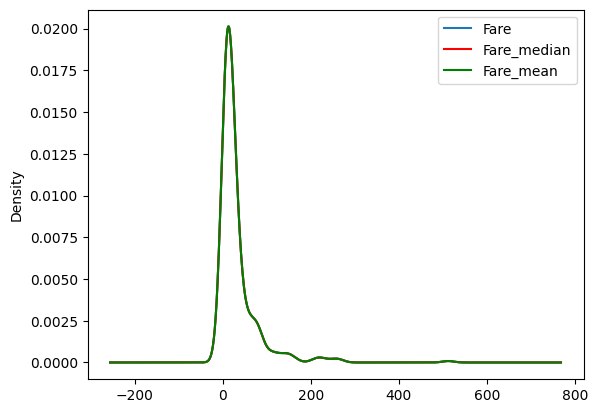

In [14]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

<Axes: >

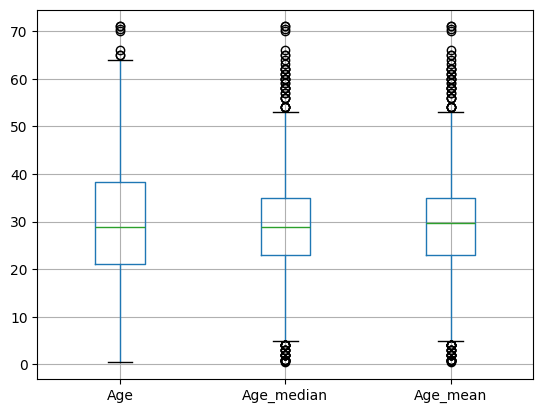

In [15]:

X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

In [16]:
X_train_df = pd.DataFrame(X_train)

X_train_df.corr(numeric_only=True)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Age_median,Age_mean,Fare_median,Fare_mean
PassengerId,1.000000,-0.007051,0.011997,-0.065879,0.009706,0.022869,0.011254,0.010742,0.022869,0.022869
Pclass,-0.007051,1.000000,-0.380253,0.105173,0.033555,-0.558653,-0.344960,-0.339066,-0.558653,-0.558653
Age,0.011997,-0.380253,1.000000,-0.309514,-0.182537,0.095814,1.000000,1.000000,0.095814,0.095814
SibSp,-0.065879,0.105173,-0.309514,1.000000,0.400103,0.156335,-0.231075,-0.230260,0.156335,0.156335
Parch,0.009706,0.033555,-0.182537,0.400103,1.000000,0.202116,-0.168073,-0.172557,0.202116,0.202116
Fare,0.022869,-0.558653,0.095814,0.156335,0.202116,1.000000,0.095235,0.091475,1.000000,1.000000
Age_median,0.011254,-0.344960,1.000000,-0.231075,-0.168073,0.095235,1.000000,0.999454,0.095235,0.095235
Age_mean,0.010742,-0.339066,1.000000,-0.230260,-0.172557,0.091475,0.999454,1.000000,0.091475,0.091475
Fare_median,0.022869,-0.558653,0.095814,0.156335,0.202116,1.000000,0.095235,0.091475,1.000000,1.000000
Fare_mean,0.022869,-0.558653,0.095814,0.156335,0.202116,1.000000,0.095235,0.091475,1.000000,1.000000


In [17]:
X_train_df = pd.DataFrame(X_train)

X_train_df.cov(numeric_only=True)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Age_median,Age_mean,Fare_median,Fare_mean
PassengerId,67083.511868,-1.530927,44.696863,-19.213776,2.116239,288.248615,37.097298,35.392875,288.248615,288.248615
Pclass,-1.530927,0.702784,-4.566284,0.099283,0.023681,-22.791180,-3.680637,-3.615778,-22.791180,-22.791180
Age,44.696863,-4.566284,204.349513,-4.165283,-2.333618,71.512440,204.349513,204.349513,71.512440,71.512440
SibSp,-19.213776,0.099283,-4.165283,1.267996,0.379281,8.567003,-3.311738,-3.298248,8.567003,8.567003
Parch,2.116239,0.023681,-2.333618,0.379281,0.708695,8.280261,-1.800826,-1.847858,8.280261,8.280261
Fare,288.248615,-22.791180,71.512440,8.567003,8.280261,2368.246832,58.986531,56.626587,2368.246832,2368.246832
Age_median,37.097298,-3.680637,204.349513,-3.311738,-1.800826,58.986531,161.989566,161.812625,58.986531,58.986531
Age_mean,35.392875,-3.615778,204.349513,-3.298248,-1.847858,56.626587,161.812625,161.812625,56.626587,56.626587
Fare_median,288.248615,-22.791180,71.512440,8.567003,8.280261,2368.246832,58.986531,56.626587,2368.246832,2368.246832
Fare_mean,288.248615,-22.791180,71.512440,8.567003,8.280261,2368.246832,58.986531,56.626587,2368.246832,2368.246832


<Axes: >

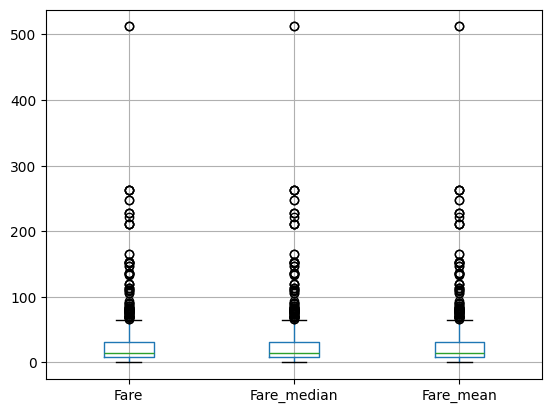

In [18]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

In [19]:
#Using Sklearn

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [21]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [22]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [23]:

trf.fit(X_train)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [24]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [25]:
trf.named_transformers_['imputer2'].statistics_

array([32.28905604])

In [26]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [27]:

X_train

array([[40.0, 27.7208, 31, ..., 'PC 17601', nan, 'C'],
       [4.0, 16.7, 11, ..., 'PP 9549', 'G6', 'S'],
       [47.0, 9.0, 874, ..., '345765', nan, 'S'],
       ...,
       [71.0, 49.5042, 494, ..., 'PC 17609', nan, 'C'],
       [28.75, 221.7792, 528, ..., 'PC 17483', 'C95', 'S'],
       [28.75, 25.925, 169, ..., 'PC 17318', nan, 'S']],
      shape=(712, 11), dtype=object)